In [8]:
from langchain_core.messages import BaseMessage, ChatMessage, HumanMessage
from typing import TypedDict, Any, List, Optional, Annotated
from langgraph.graph import StateGraph , START , END
from langgraph.graph.message import add_messages
from langchain_ollama import ChatOllama, OllamaLLM
from langgraph.checkpoint.memory import MemorySaver, InMemorySaver

In [2]:
class Chatstate (TypedDict):
    messages : Annotated[List[BaseMessage], add_messages]

In [3]:
llm = ChatOllama(
    model="llama3.2",
    temperature=0
)

In [ ]:

def chat_node(state: Chatstate):
    # take user query
    messages = state['messages']
    
    # send to llm
    response = llm.invoke(messages)
    
    # reponse store state
    return {'messages':[response]}

In [4]:
checkpointer = MemorySaver()
graph = StateGraph(Chatstate)
graph.add_node('chat_node', chat_node)
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer = checkpointer)

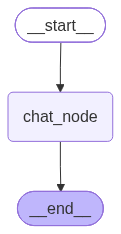

In [5]:
chatbot

In [6]:
initial_state = {'messages': [HumanMessage(content="what is capital of india")]}

chatbot.invoke(initial_state)['messages'][-1].content

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [7]:
thread_id = 1 
while True:
    user_input = input("User:....")
    print("USER..", user_input)
    if user_input.lower() in ['exit', 'quit']:
        break
    
    config = {'configurable': {'thread_id': thread_id}}
    response = chatbot.invoke({'messages': [HumanMessage(content=user_input)]}, config=config)
    
    print("AI:", response['messages'][-1].content)
    

USER.. hii my name is chandan


Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


AI: Namaste Chandan! It's nice to meet you. Is there something I can help you with or would you like to chat?


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


USER.. my father name is jograj


...

USER.. noida is city or not


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


AI: Noida is a city in the state of Uttar Pradesh, India. It is a part of the National Capital Region (NCR) and is known for its industrial and commercial development.


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


USER.. exit


In [8]:
snaps = chatbot.get_state(config=config)
vals = snaps.values
for m in vals.get("messages",[]):
    print("--", type(m).__name__,":",m.content)

-- HumanMessage : hii my name is chandan
-- AIMessage : Namaste Chandan! It's nice to meet you. Is there something I can help you with or would you like to chat?
-- HumanMessage : my father name is jograj
-- AIMessage : Namaste Chandan! Nice to know your father's name is Jograj. How's your family doing?
-- HumanMessage : what is chandan father name
-- AIMessage : You mentioned earlier that your father's name is Jograj, not Chandan.
-- HumanMessage : jograj daughter name is charu
-- AIMessage : So, to recap, we have:

* Father's name: Jograj
* Daughter's name: Charu
* Your name: Chandan

Is that correct?
-- HumanMessage : what is chandan sister name
-- AIMessage : We don't have any information about Chandan having a sister. We only know about Chandan, his father Jograj, and his sister Charu.
-- HumanMessage : what is capital of harayan
-- AIMessage : The capital of Haryana is Chandigarh.
-- HumanMessage : noida is city or not
-- AIMessage : Noida is a city in the state of Uttar Pradesh,

In [4]:
from langchain_core.messages.utils import trim_messages, count_tokens_approximately

In [14]:
def call_state(state: Chatstate):
    messages = trim_messages(
        state["messages"],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=150
    )
    print("count token", count_tokens_approximately(messages=messages))
    for message in messages:
        print(message.content)
        
    response = llm.invoke(message)
    
    return {"message": [response]}

In [6]:
builder = StateGraph(Chatstate)
builder.add_node("call_state", call_state)
builder.add_edge(START,"call_state" )


In [9]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

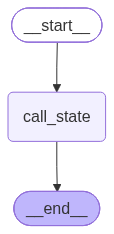

In [10]:
graph

In [12]:
config = {"configurable": {"thread_id": "thread_1"}}

result = graph.invoke(
    {"messages":[{"role": "user","content":"hi, my name is chandan"}]},
    config=config
)
result["messages"][-1].content

count token 20
hi, my name is chandan
hi, my name is chandan


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


'hi, my name is chandan'

In [13]:
result = graph.invoke(
    {"messages":[{"role": "user","content":"can you explain short term memory"}]},
    config=config
)
result["messages"][-1].content

count token 33
hi, my name is chandan
hi, my name is chandan
can you explain short term memory


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


'can you explain short term memory'

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [15]:
result = graph.invoke(
    {"messages":[{"role": "user","content":"can you explain short term memory"}]},
    config=config
)
result["messages"][-1].content

count token 46
hi, my name is chandan
hi, my name is chandan
can you explain short term memory
can you explain short term memory


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


'can you explain short term memory'

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [16]:
from langchain_core.messages import RemoveMessage

In [17]:
def chat(state:Chatstate):
    response = llm.invoke(state["messages"])
    return {"messages":[response]}

def delete_old_message(state:Chatstate):
    msgs = state["messages"]
    
    # if more than 6 messages delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:-6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}
    
    return {}

In [18]:
builder1 = StateGraph(Chatstate)
builder1.add_node("chat", chat)
builder1.add_node("cleanup", delete_old_message)

builder1.add_edge(START, "chat")
builder1.add_edge("chat", "cleanup")
builder1.add_edge("cleanup", "__end__")

In [23]:
graph1 = builder1.compile(checkpointer= checkpointer)

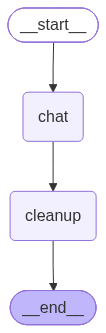

In [24]:
graph1

In [26]:
from langchain_core.runnables import RunnableConfig

config = {"configurable": {"thrad_id":"td1"}}
config: RunnableConfig = {
    "configurable": {"thread_id": "td1"}
}

messages = [
    "what is my name",
    "hii",
    "tell me something",
    "how about you",
    "pleasure",
]

for text in messages:
    result = graph1.invoke(
        {"messages": [HumanMessage(content=text)]},
        config=config,
    )
    print("AI:", result["messages"][-1].content)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


AI: I don't have any information about your name. I'm a large language model, I don't have the ability to store or access personal data about individuals. Each time you interact with me, it's a new conversation and I don't retain any information from previous conversations. If you'd like to share your name with me, I'd be happy to chat with you!


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


AI: Hi! It's nice to meet you, even if I don't know your name. How's your day going so far?


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


AI: Did you know that there is a species of jellyfish that is immortal? The Turritopsis dohrnii, also known as the "immortal jellyfish," is a type of jellyfish that can transform its body into a younger state through a process called transdifferentiation. This means that it can essentially revert back to its polyp stage, which is the juvenile form of a jellyfish, and then grow back into an adult again. This process can be repeated indefinitely, making the Turritopsis dohrnii theoretically immortal. Isn't that cool?


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


AI: I'm just a computer program, so I don't have feelings, emotions, or personal experiences like humans do. I exist solely to process and generate text to assist and communicate with users like you.

I don't have a physical body, a personal life, or a sense of self. I'm simply a collection of code and data that runs on computer servers, responding to inputs and generating outputs based on my programming and training.

That being said, I'm designed to be helpful and engaging, so I'm always happy to chat with you and provide information, answer questions, or just have a conversation!
AI: It was a pleasure chatting with you too! If you want to talk more or need help with anything, feel free to start a conversation anytime. Have a great day!


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [29]:
snap = graph1.get_state(config)

print("stored messages after cleanup", len(snap.values["messages"]))
# print("stord messages after cleanup", len(snap.values["messages"]))

stored messages after cleanup 10


summary state

In [30]:
class chat1(Chatstate):
    summary : str

In [32]:
def summary_node (state: chat1):
    messages = []
    if state["summary"]:
        messages.append(
            {"role":"system",
             "content":f"converstion memeroy:\n{state["summary"]}"}
        )
    messages.extend(state["messages"])
    print(messages)
    
    response = llm.invoke(messages)
    return {"messages" : [response]}

In [33]:
def summary (state:chat1):
    exisitng_summary = state["summary"]
    
    if exisitng_summary :
        prompt = (
            f"Existing summary:\n{exisitng_summary}\n\n"
            "Existing the summary using the new conversation above."
        )
    else:
        prompt ="summarize the converstion above."
        
    messages_for_summary = state["summary"] + [HumanMessage(content=prompt)]
    
    response = llm.invoke(messages_for_summary)
    # keep only last two messages
    
    messages_to_delete = state["summary"][:-2]
    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete]
    }

In [34]:
def  should_summary(state:chat1):
    return len(state["messages"]) > 6 

In [36]:
builder2 = StateGraph(Chatstate)

builder2.add_node("chat", summary_node)
builder2.add_node("summarize", summary)

builder2.add_edge(START, "chat")
builder2.add_conditional_edges(
    "chat",
    should_summary,
    {True: "summarize",
     False:"__end__"}
)

builder2.add_edge("summarize",  "__end__")

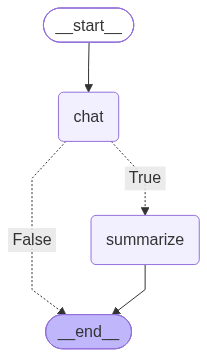

In [37]:
graph2 = builder2.compile(checkpointer= checkpointer)
graph2

In [38]:
config = {"configurable": {"thread_id": "td12"}}

In [40]:
# give the current version of hte state
def show_state():
    snap = graph2.get_state(config)
    vals = snap.values
    print("\n ---state---")
    print("summary:", vals.get("summary",""))
    print("num_messages:", len(vals.get("messages",[])))
    print("messages")
    
    for m in vals.get("messages",[]):
        print("-", type(m).__name__,":",m.content[:80])

In [42]:
config: RunnableConfig = {"configurable": {"thread_id": "td12"}}

out = graph2.invoke(
    {"messages": [HumanMessage(content="quantum physics")], "summary": ""},
    config=config,
)

print(out)
show_state()

KeyError: 'summary'

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
